In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install --quiet optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 17.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 9.3 MB/s eta 0:00:00


In [ ]:
data = pd.read_csv('water_potability.csv')
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
data.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [ ]:
data["ph"].fillna(value=data["ph"].mean(), inplace=True)
data["Sulfate"].fillna(value=data["Sulfate"].mean(), inplace=True)
data["Trihalomethanes"].fillna(value=data["Trihalomethanes"].mean(), inplace=True)
data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [ ]:
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [ ]:
data = data.sample(frac=1, random_state=24).reset_index(drop=True)
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,210.627359,27983.179422,5.947213,333.775777,436.844053,16.127527,64.564044,4.290393,1
1,6.971577,185.906938,27959.987873,7.214510,349.743879,414.067354,19.882917,36.179003,3.226349,0
2,5.963479,223.031638,24435.642080,6.221292,305.947012,284.497026,15.188557,40.142705,3.727813,0
3,6.709336,226.427586,8238.290038,7.692413,289.921380,284.774459,11.868480,51.875207,4.074387,0
4,6.433722,177.252511,20321.229404,6.378918,373.051772,375.028222,11.684648,61.629823,3.641490,1
...,...,...,...,...,...,...,...,...,...,...
3271,7.080795,194.719186,18344.069444,7.611837,333.775777,320.356014,12.333237,75.114888,4.515322,0
3272,8.716820,153.980034,11734.448857,7.123611,333.775777,447.028077,12.736044,39.927521,3.205129,1
3273,6.323040,227.553972,24463.137418,6.261934,333.775777,399.947453,17.912652,71.151222,4.749424,0
3274,8.080415,166.891700,18136.128859,6.867553,333.775777,600.937203,16.307790,55.586142,4.070824,0


### Complete model

In [ ]:
columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
X = data[columns]
y = data.Potability

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=124)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tamanho do modelo em bytes: 6594373
              precision    recall  f1-score   support

           0       0.69      0.92      0.79       562
           1       0.73      0.34      0.46       356

    accuracy                           0.69       918
   macro avg       0.71      0.63      0.62       918
weighted avg       0.70      0.69      0.66       918



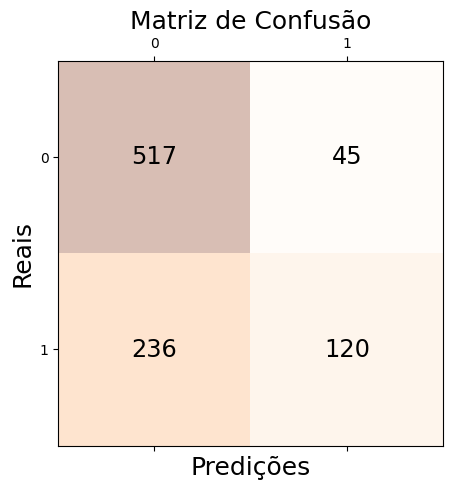

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import sys

rfc_best = RandomForestClassifier(class_weight='balanced')


rfc_best.fit(X_train_scaled, y_train)
p = pickle.dumps(rfc_best)
print('Tamanho do modelo em bytes:', sys.getsizeof(p))

y_pred = rfc_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predições', fontsize=18)
plt.ylabel('Reais', fontsize=18)
plt.title('Matriz de Confusão', fontsize=18)
plt.show()

### Reduced model

In [ ]:
columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Conductivity', 'Turbidity']
X = data[columns]
y = data.Potability

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=124)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Tamanho do modelo em bytes: 7485022
              precision    recall  f1-score   support

           0       0.63      0.83      0.72       562
           1       0.47      0.24      0.32       356

    accuracy                           0.60       918
   macro avg       0.55      0.54      0.52       918
weighted avg       0.57      0.60      0.56       918



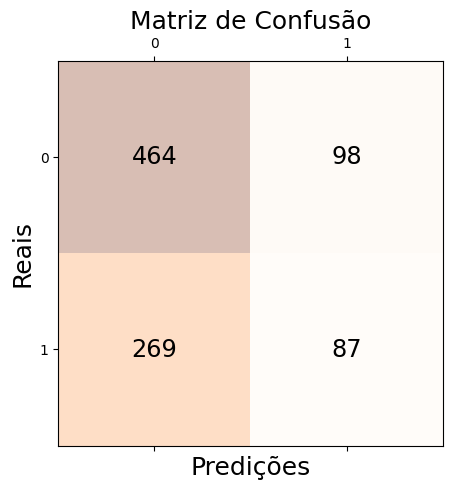

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import sys

rfc_best = RandomForestClassifier(class_weight='balanced')


rfc_best.fit(X_train_scaled, y_train)
p = pickle.dumps(rfc_best)
print('Tamanho do modelo em bytes:', sys.getsizeof(p))

y_pred = rfc_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predições', fontsize=18)
plt.ylabel('Reais', fontsize=18)
plt.title('Matriz de Confusão', fontsize=18)
plt.show()

### Balancing Ivanov + Optuna

In [ ]:
columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Conductivity', 'Turbidity']

data_equal = data.groupby('Potability').sample(data.groupby('Potability').size().min())

X = data_equal[columns]
y = data_equal.Potability

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting Dataset
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(X, y, test_size=0.28, random_state = 124, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_set)
X_test_scaled = scaler.transform(X_test_set)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Conductivity', 'Turbidity']

data_equal = data.groupby('Potability').sample(data.groupby('Potability').size().min())

X = data_equal[columns]
y = data_equal.Potability

# Splitting Dataset
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(X, y, test_size=0.28, random_state = 124, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_set)
X_test_scaled = scaler.transform(X_test_set)

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import pickle
import sys

def objective(trial):
    params = {
            "n_estimators": trial.suggest_int(name="rf_n_estimators", low=50, high=190, step=20),
            "max_features": trial.suggest_categorical(name="rf_max_features", choices=['log2', 'sqrt']),
            "max_depth": trial.suggest_int(name="rf_max_depth", low=10, high=190, step=30),
            "min_samples_split": trial.suggest_int(name="rf_min_samples_split", low=2, high=10, step=2),
            "min_samples_leaf": trial.suggest_int(name="rf_min_samples_leaf", low=1, high=4, step=1),
            "criterion": trial.suggest_categorical('rf_criterion', choices=['gini', 'entropy', 'log_loss'])
        }

    splits_number = 5

    cv = StratifiedKFold(n_splits=splits_number, shuffle=True, random_state=124)
    cv_scores = np.empty(splits_number)
    cv_model_size_bytes = np.empty(splits_number)

    for idx, (train_idx, test_idx) in enumerate(cv.split(X_train_scaled, y_train_set)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(class_weight='balanced', random_state=124, **params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        cv_scores[idx] = f1_score(y_test, preds)
        print("Testing F1-Score {:.4f}".format(cv_scores[idx]))
        p = pickle.dumps(model)
        cv_model_size_bytes[idx] = sys.getsizeof(p)

    return np.mean(cv_scores), np.mean(cv_model_size_bytes)

study = optuna.create_study(directions=['maximize','minimize'])
study.optimize(objective, n_trials=30)

[I 2024-05-25 00:30:58,835] A new study created in memory with name: no-name-f968c278-8acb-4b92-8fda-07371ca2d725


Testing F1-Score 0.2400
Testing F1-Score 0.1818
Testing F1-Score 0.2466
Testing F1-Score 0.1733


[I 2024-05-25 00:31:04,969] Trial 0 finished with values: [0.2052248041475672, 2703350.0] and parameters: {'rf_n_estimators': 90, 'rf_max_features': 'sqrt', 'rf_max_depth': 160, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 1, 'rf_criterion': 'entropy'}. 


Testing F1-Score 0.1844
Testing F1-Score 0.2826
Testing F1-Score 0.2905
Testing F1-Score 0.3314
Testing F1-Score 0.3131


[I 2024-05-25 00:31:17,600] Trial 1 finished with values: [0.29072528593758457, 2057585.2] and parameters: {'rf_n_estimators': 190, 'rf_max_features': 'log2', 'rf_max_depth': 10, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 1, 'rf_criterion': 'entropy'}. 


...

Testing F1-Score 0.1935
Testing F1-Score 0.2152
Testing F1-Score 0.1867
Testing F1-Score 0.2893
Testing F1-Score 0.2390


[I 2024-05-25 00:33:02,656] Trial 28 finished with values: [0.21890839770413534, 2753354.8] and parameters: {'rf_n_estimators': 110, 'rf_max_features': 'sqrt', 'rf_max_depth': 70, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 2, 'rf_criterion': 'log_loss'}. 


Testing F1-Score 0.1644
Testing F1-Score 0.2125
Testing F1-Score 0.2138
Testing F1-Score 0.2609
Testing F1-Score 0.2767


[I 2024-05-25 00:33:05,488] Trial 29 finished with values: [0.2314967980100029, 2072703.0] and parameters: {'rf_n_estimators': 90, 'rf_max_features': 'log2', 'rf_max_depth': 130, 'rf_min_samples_split': 10, 'rf_min_samples_leaf': 1, 'rf_criterion': 'log_loss'}. 


Testing F1-Score 0.1935


In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["F1-Score", "Model Size"])

Tamanho do modelo em bytes: 1472110
              precision    recall  f1-score   support

           0       0.60      0.62      0.61       358
           1       0.61      0.58      0.59       358

    accuracy                           0.60       716
   macro avg       0.60      0.60      0.60       716
weighted avg       0.60      0.60      0.60       716



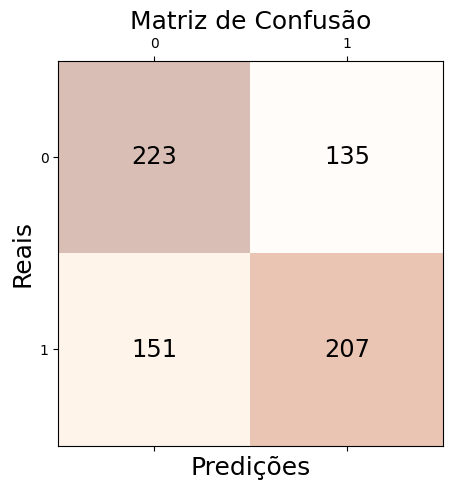

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import sys

rfc_best = RandomForestClassifier(random_state=124,
                                  class_weight='balanced',
                                  max_features='sqrt',
                                  n_estimators=130,
                                  max_depth=10,
                                  min_samples_split=4,
                                  min_samples_leaf=4,
                                  criterion='log_loss')



rfc_best.fit(X_train_scaled, y_train_set)
p = pickle.dumps(rfc_best)
print('Tamanho do modelo em bytes:', sys.getsizeof(p))

y_pred = rfc_best.predict(X_test_scaled)
print(classification_report(y_test_set, y_pred))

conf_matrix = confusion_matrix(y_true=y_test_set, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predições', fontsize=18)
plt.ylabel('Reais', fontsize=18)
plt.title('Matriz de Confusão', fontsize=18)
plt.show()

### Balancing Ivanov

In [ ]:
columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Conductivity', 'Turbidity']

data_equal = data.groupby('Potability').sample(data.groupby('Potability').size().min())

X = data_equal[columns]
y = data_equal.Potability

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting Dataset
X_train_set, X_test_set, y_train_set, y_test_set = train_test_split(X, y, test_size=0.28, random_state = 124, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_set)
X_test_scaled = scaler.transform(X_test_set)

Tamanho do modelo em bytes: 6267808
              precision    recall  f1-score   support

           0       0.56      0.60      0.58       350
           1       0.59      0.55      0.57       366

    accuracy                           0.57       716
   macro avg       0.57      0.57      0.57       716
weighted avg       0.57      0.57      0.57       716



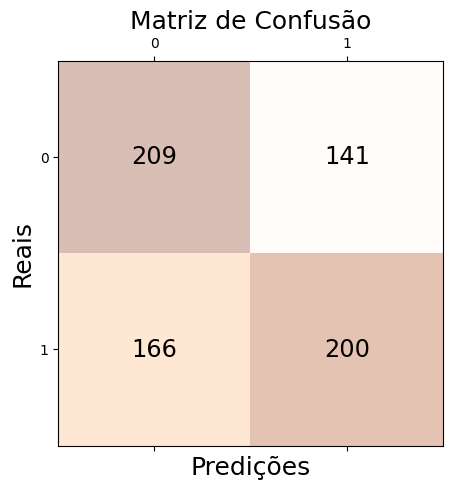

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import sys

rfc_best = RandomForestClassifier(class_weight='balanced')


rfc_best.fit(X_train_scaled, y_train)
p = pickle.dumps(rfc_best)
print('Tamanho do modelo em bytes:', sys.getsizeof(p))

y_pred = rfc_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predições', fontsize=18)
plt.ylabel('Reais', fontsize=18)
plt.title('Matriz de Confusão', fontsize=18)
plt.show()

### Embedding model

In [ ]:
!pip install --quiet emlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import emlearn

best_model = rfc_best

path = 'rfc_model.h'
cmodel = emlearn.convert(best_model, method='inline')
cmodel.save(file=path, name='rfc_model')

'\n\n\n    // !!! This file is generated using emlearn !!!\n\n    #include <eml_trees.h>\n    \n\nstatic const EmlTreesNode rfc_model_nodes[9875] = {\n  { 5, 2.280779f, 1, 39 },\n  { 3, 2.554538f, 1, -1 },\n  { 0, -1.772457f, 1, 9 },\n  { 2, -0.210363f, 1, 4 },\n  { 3, -0.269667f, 1, 2 },\n  { 2, -0.673099f, -2, -1 },\n  { 0, -2.054887f, -2, -2 },\n  { 5, -0.251624f, -2, 1 },\n  { 2, 0.487684f, 1, 2 },\n  { 3, 0.030894f, -2, -2 },\n  { 0, -2.272176f, -1, -2 },\n  { 0, 0.941083f, 1, 13 },\n  { 4, -1.895464f, 1, 3 },\n  { 3, -0.244438f, -2, 1 },\n  { 0, -0.248565f, -1, -2 },\n  { 0, 0.926569f, 1, -1 },\n  { 4, -1.840740f, -1, 1 },\n  { 2, 1.383710f, 1, 4 },\n  { 4, -1.641709f, 1, 2 },\n  { 4, -1.694338f, -2, -2 },\n  { 3, -2.204938f, -1, -1 },\n  { 5, -0.240844f, 1, 2 },\n  { 3, -0.820098f, -1, -1 },\n  { 3, 0.330304f, -1, -2 },\n  { 1, -2.735118f, -1, 1 },\n  { 3, -0.153116f, 1, 7 },\n  { 2, -1.364691f, -2, 1 },\n  { 1, 0.541565f, 1, 3 },\n  { 1, 0.284071f, 1, -2 },\n  { 0, 1.209994f, -

In [ ]:
scaled_test_df = pd.DataFrame(X_test_scaled, index=X_test_set.index, columns=X_test_set.columns)
for (columnName, columnData) in scaled_test_df.items():
    #print('Column Name : ', columnName)
    elements = columnData.values.flatten()
    print('float ' + columnName.lower() + '[] = ', end='')
    print('{', end='')
    for index, value in enumerate(elements):
      print(value, end='')
      if index != len(elements) - 1:
        print(', ', end='')
    print('};')

elements = y_test_set.to_numpy().flatten()
print('int expected_result[] = ', end='')
print('{', end='')
for index, value in enumerate(elements):
  print(value, end='')
  if index != len(elements) - 1:
    print(', ', end='')
print('};')

float ph[] = {0.1475318715710195, 2.4112042584388274, 0.18830781250293988, -0.7153261403846795, -0.1380919902209435, -1.0968743131990024, -0.5911110979101148, -0.6321417021476051, -1.2060243869646303, -0.5381195603993894, -0.016474051482110168, -0.016474051482110168, 1.0491299066161082, -0.016474051482110168, 0.3368068501316159, -0.1545108015694852, -0.14581109468499628, 0.20045296358117567, -0.36073300239360667, -1.2578916598418228, -1.240727918792344, -0.7281894832174471, -2.4538954653678555, 0.6093234691743216, 4.27985954156808, -0.3656621402785764, -1.306120324674618, -0.7277274357656475, 1.0002383315758199, -0.016474051482110168, 0.7320778991586482, 0.3212330506279169, 1.4644399886496557, -1.3604062301843518, 2.059831876385058, -0.4835613944096721, -1.0597277234915965, -0.2799005430203044, 2.23060755950437, 1.5347525593539568, 0.5144702088033659, -0.39204987553524134, 0.13875069625876474, -0.26574741690332904, -0.33282508221003204, -1.5389338110507003, -1.4848813247600618, -0.0057

In [ ]:
with open('RandomForestClassifier.h', 'w') as file:
        file.write(clf.to_arduino(instance_name='rfClassifier'))

In [ ]:
scaled_test_df = pd.DataFrame(X_test_scaled, index=X_test_set.index, columns=X_test_set.columns)

In [ ]:
for (columnName, columnData) in scaled_test_df.items():
    #print('Column Name : ', columnName)
    elements = columnData.values.flatten()
    print('float ' + columnName.lower() + '[] = ', end='')
    print('{', end='')
    for index, value in enumerate(elements):
      print(value, end='')
      if index != len(elements) - 1:
        print(', ', end='')
    print('};')

float ph[] = {-0.14615369226606129, 0.11372697770880495, 1.2089882901461315, -0.4340084158324962, 0.0032798123254575077, 1.2012783219530263, 0.0032798123254575077, -1.1570664958166441, -2.3666317533961263, 0.5494275231113911, -1.4746651101132235, 0.4199701718053853, -0.37903228859504906, -1.2334282252933113, 0.0032798123254575077, -0.21957334708730802, 0.0032798123254575077, 0.0032798123254575077, -0.644321616829932, 0.6948106952779503, -0.2079583948127488, 0.21046646566320254, 0.41732771098586474, -0.9696261252301149, 1.0931730026873663, 2.232744991843027, -0.9322409219732555, 0.17081895550676518, 0.299931856786614, 0.7170617684546665, -0.09965889429658076, 0.0032798123254575077, 1.5948258201452583, -0.7609411255379324, 0.369271565579132, 1.433228898128773, -0.9519814422826496, 0.0032798123254575077, 0.0032798123254575077, -0.722579148063689, 0.5501692595333391, 1.6741200085043229, 0.5528120929201324, 1.6680798553707563, 0.0032798123254575077, 0.20773658577777981, 1.3680404760415368, 

In [ ]:
elements = y_test_set.to_numpy()

elements = elements.flatten()
print('int expected_result[] = ', end='')
print('{', end='')
for index, value in enumerate(elements):
  print(value, end='')
  if index != len(elements) - 1:
    print(', ', end='')
print('};')

int expected_result[] = {1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 

In [ ]:
y_test

1087    0
610     0
1376    1
3188    1
2623    0
       ..
1161    0
1744    0
1820    1
1169    0
2084    0
Name: Potability, Length: 716, dtype: int64

### Save model

In [ ]:
rfc_best.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'log_loss',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 4,
 'min_samples_split': 4,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 130,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 124,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(accuracy_score(y_test_set, y_pred))
print(precision_score(y_test_set, y_pred))
print(recall_score(y_test_set, y_pred))
print(f1_score(y_test_set, y_pred))

0.6005586592178771
0.6052631578947368
0.5782122905027933
0.5914285714285714


In [ ]:
!pip install --quiet pycm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.8/601.8 kB 12.3 MB/s eta 0:00:00


In [ ]:
from pycm import *

print(ConfusionMatrix(actual_vector=y_test_set.to_numpy().flatten(), predict_vector=y_pred))

Predict   0         1         
Actual
0         223       135       

1         151       207       





Overall Statistics : 

95% CI                                                            (0.56468,0.63643)
ACC Macro                                                         0.60056
ARI                                                               0.03911
AUNP                                                              0.60056
AUNU                                                              0.60056
Bangdiwala B                                                      0.36117
Bennett S                                                         0.20112
CBA                                                               0.58723
CSI                                                               0.20132
Chi-Squared                                                       29.01886
Chi-Squared DF                                                    1
Conditional Entropy                                 

In [ ]:
from joblib import dump, load

dump(rfc_best, open("random_forest.joblib", "wb"))

In [ ]:
scaled_test_df
scaled_test_df.to_pickle("test_df.pkl")

In [ ]:
y_test_set
y_test_set.to_pickle("test_expect.pkl")

### Load model

In [ ]:
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rfc_best = joblib.load('random_forest.joblib')
test_df = pd.read_pickle("test_df.pkl")
test_expect = pd.read_pickle("test_expect.pkl")
y_pred = rfc_best.predict(test_df)

print(accuracy_score(test_expect, y_pred))
print(precision_score(test_expect, y_pred))
print(recall_score(test_expect, y_pred))
print(f1_score(test_expect, y_pred))

0.6005586592178771
0.6052631578947368
0.5782122905027933
0.5914285714285714


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from pycm import *

print(ConfusionMatrix(actual_vector=test_expect.to_numpy().flatten(), predict_vector=y_pred))

Predict   0         1         
Actual
0         223       135       

1         151       207       





Overall Statistics : 

95% CI                                                            (0.56468,0.63643)
ACC Macro                                                         0.60056
ARI                                                               0.03911
AUNP                                                              0.60056
AUNU                                                              0.60056
Bangdiwala B                                                      0.36117
Bennett S                                                         0.20112
CBA                                                               0.58723
CSI                                                               0.20132
Chi-Squared                                                       29.01886
Chi-Squared DF                                                    1
Conditional Entropy                                 